<a href="https://colab.research.google.com/github/aishaneedas19-ai/Loan_Automation/blob/main/loan_automation.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [81]:
!pip install seaborn
!pip install imblearn
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report, precision_recall_curve, average_precision_score
from imblearn.over_sampling import SMOTE


In [82]:
df = pd.read_csv("credit_dataset_5000_enhanced_final.csv")



In [83]:
print(df.head())



   Age  Income  Coapplicant_Income  Dependents  Employ_Status   Debt  \
0   61   26587               10296           1       Employed  56824   
1   36   23236               13264           3  Self-employed  78620   
2   66   19245               32648           5       Employed  34596   
3   29   64148               19563           1       Employed  59612   
4   43  101424               49221           1     Unemployed   1523   

   PrevLDefault  CIBIL_Score  Loan_Approval  
0             1          465              0  
1             1          456              1  
2             0          572              0  
3             0          620              0  
4             0          659              0  


In [84]:
import numpy as np

score = (
    (df['CIBIL_Score'] - df['CIBIL_Score'].mean()) / df['CIBIL_Score'].std() * 2.5
    - df['PrevLDefault'] * 2.0
    - (df['Debt'] / df['Income'].replace(0, np.nan).fillna(df['Income'].mean())) * 1.5
    + (df['Income'] - df['Income'].mean()) / df['Income'].std() * 1.0
    - df['Dependents'] * 0.15
    + np.where(df['Employ_Status'] == 'Employed', 0.5,
        np.where(df['Employ_Status'] == 'Self-employed', 0.2, -0.8))
)

score += np.random.normal(0, 1.8, size=len(df))
threshold = score.median()
df['Loan_Approval'] = (score > threshold).astype(int)

print(df['Loan_Approval'].value_counts(normalize=True))

Loan_Approval
0    0.5
1    0.5
Name: proportion, dtype: float64


In [85]:
from sklearn.preprocessing import LabelEncoder

df["Employ_Status"] = df["Employ_Status"].astype(str)

le = LabelEncoder()
df["Employ_Status"] = le.fit_transform(df["Employ_Status"])

In [86]:
X = df.drop("Loan_Approval", axis=1)
y = df["Loan_Approval"]

In [87]:
print("Class distribution:")
print(y.value_counts())
print("Percentage:")
print(y.value_counts(normalize=True) * 100)

Class distribution:
Loan_Approval
0    2500
1    2500
Name: count, dtype: int64
Percentage:
Loan_Approval
0    50.0
1    50.0
Name: proportion, dtype: float64


In [88]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.6, random_state=42, stratify=y
)

sm = SMOTE(random_state=42)
X_train_res, y_train_res = sm.fit_resample(X_train, y_train)

scaler = StandardScaler()
X_train_res_scaled = scaler.fit_transform(X_train_res)
X_test_scaled = scaler.transform(X_test)
X_train_scaled = scaler.transform(X_train)

In [89]:
lr = LogisticRegression(
    random_state=42,
    class_weight="balanced",
    max_iter=1000,
    C=0.05
)

lr.fit(X_train_res_scaled, y_train_res)

# Evaluate baseline
print("Train Accuracy:", accuracy_score(y_train, lr.predict(X_train_scaled)))
print("Test Accuracy:", accuracy_score(y_test, lr.predict(X_test_scaled)))

Train Accuracy: 0.892
Test Accuracy: 0.8846666666666667


In [90]:
from sklearn.model_selection import GridSearchCV

param_grid = {
    'C': [0.01, 0.1, 1, 10, 100],
    'penalty': ['l1', 'l2'],
    'solver': ['liblinear', 'saga']
}

lr_base = LogisticRegression(random_state=42, class_weight="balanced", max_iter=1000)

grid_search = GridSearchCV(
    estimator=lr_base,
    param_grid=param_grid,
    cv=3,
    n_jobs=-1,
    verbose=2,
    scoring='accuracy'
)

grid_search.fit(X_train_scaled, y_train)

print("Best parameters found: ", grid_search.best_params_)
print("Best cross-validation accuracy: {:.2f}".format(grid_search.best_score_))

best_lr = grid_search.best_estimator_

y_pred_tuned = best_lr.predict(X_test_scaled)
tuned_accuracy = accuracy_score(y_test, y_pred_tuned)
print("Tuned Test Accuracy: {:.2f}%".format(tuned_accuracy * 100))

Fitting 3 folds for each of 20 candidates, totalling 60 fits
Best parameters found:  {'C': 0.1, 'penalty': 'l1', 'solver': 'liblinear'}
Best cross-validation accuracy: 0.90
Tuned Test Accuracy: 88.90%


In [91]:
y_pred = lr.predict(X_test_scaled)

In [92]:
from sklearn.metrics import accuracy_score

accuracy = accuracy_score(y_test, y_pred)
print("Test Accuracy:", accuracy)

Test Accuracy: 0.8846666666666667


In [93]:
print("Train Accuracy:", accuracy_score(y_train, lr.predict(X_train_scaled)))
print("Test Accuracy:", accuracy_score(y_test, lr.predict(X_test_scaled)))

Train Accuracy: 0.892
Test Accuracy: 0.8846666666666667


In [94]:
from sklearn.model_selection import cross_val_score

# Use X_train_scaled instead of unscaled X_train
cv_scores = cross_val_score(lr, X_train_scaled, y_train, cv=5, scoring='accuracy')

print("Cross-validation scores:", cv_scores)
print("Mean CV accuracy:", cv_scores.mean())

Cross-validation scores: [0.895 0.885 0.885 0.905 0.89 ]
Mean CV accuracy: 0.892


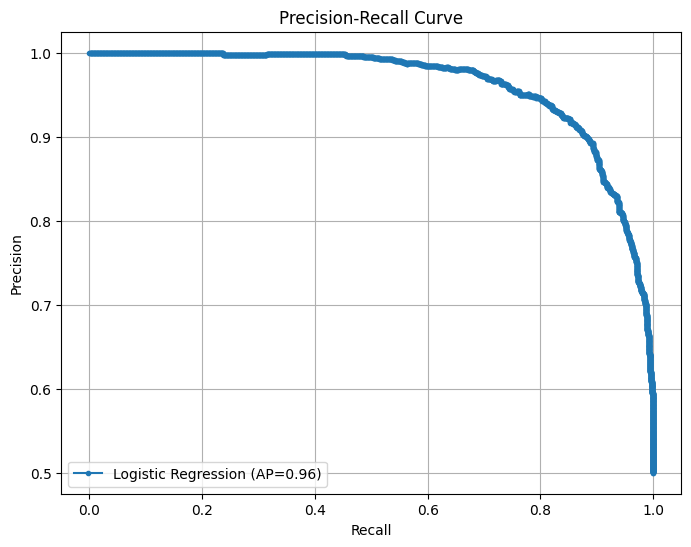


Classification report at threshold=0.4:
              precision    recall  f1-score   support

           0       0.91      0.83      0.87      1500
           1       0.84      0.92      0.88      1500

    accuracy                           0.87      3000
   macro avg       0.88      0.87      0.87      3000
weighted avg       0.88      0.87      0.87      3000

Confusion Matrix:
 [[1238  262]
 [ 122 1378]]


In [95]:
import matplotlib.pyplot as plt
from sklearn.metrics import precision_recall_curve, average_precision_score
y_proba = best_lr.predict_proba(X_test_scaled)[:, 1]

precision, recall, thresholds = precision_recall_curve(y_test, y_proba)
avg_precision = average_precision_score(y_test, y_proba)

plt.figure(figsize=(8, 6))
plt.plot(recall, precision, marker='.', label=f'Logistic Regression (AP={avg_precision:.2f})')
plt.xlabel('Recall')
plt.ylabel('Precision')
plt.title('Precision-Recall Curve')
plt.legend()
plt.grid(True)
plt.show()

threshold = 0.4
y_pred_thresh = (y_proba >= threshold).astype(int)

print(f"\nClassification report at threshold={threshold}:")
print(classification_report(y_test, y_pred_thresh))
print("Confusion Matrix:\n", confusion_matrix(y_test, y_pred_thresh))

